In [ ]:
import subprocess, os
from google.colab import userdata

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Error: {result.stderr[-500:]}")
    return result
github_token = userdata.get('GITHUB_TOKEN')
repo_url     = f"https://{github_token}@github.com/nareshmeena12/linear-attention-jet-classification.git"
run(f"git clone {repo_url}")
os.chdir("linear-attention-jet-classification")
run("pip install -q timm h5py scikit-learn")
run("pip install -q -e .")
print("Setup complete ✓")

Setup complete ✓


In [ ]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

run("pip install kaggle -q")
os.makedirs('./data', exist_ok=True)
run("kaggle kernels output nareshmeena12/dataset-preparation-ipynb -p ./data")

run("kaggle datasets download nareshmeena01/gsoc-task-2h-pretraining-data -p ./data --unzip")

import h5py
for fname, key in [
    ('cms_jet_train.h5', 'jet'),
    ('cms_jet_test.h5',  'jet'),
    ('Dataset_Specific_Unlabelled.h5', 'jet'),
]:
    path = f'./data/{fname}'
    if os.path.exists(path):
        with h5py.File(path, 'r') as f:
            print(f"  {fname:<40} {f[key].shape}")
    else:
        print(f"  {fname:<40} NOT FOUND ✗")

  cms_jet_train.h5                         (8000, 125, 125, 8)
  cms_jet_test.h5                          (2000, 125, 125, 8)
  Dataset_Specific_Unlabelled.h5           (60000, 125, 125, 8)


In [ ]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from src.utils   import CFG, set_seed, make_dirs
set_seed(42)
make_dirs()
from src.dataset import build_loaders
from src.models  import build_model
from src.mae     import MAEPretrainer, L2ViTMAE
from src.train   import run_mae, finetune, final_eval, save_result
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")
import timm
print(f"timm    : {timm.__version__}")

Channel stats not found, computing from training data...
Saved to ./results/channel_stats.npy
Device  : cuda
GPU     : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM    : 102.0 GB
PyTorch : 2.10.0+cu128
timm    : 1.0.25


In [ ]:
CFG['train_path']      = './data/cms_jet_train.h5'
CFG['test_path']       = './data/cms_jet_test.h5'
CFG['unlabelled_path'] = './data/Dataset_Specific_Unlabelled.h5'
CFG['num_workers']     = 40
CFG['pretrain_batch']  = 256
CFG['finetune_batch']  = 256

print("Paths:")
for k in ['train_path', 'test_path', 'unlabelled_path']:
    print(f"  {k:<20} {CFG[k]}")
print(f"\nBatch sizes:")
print(f"  pretrain : {CFG['pretrain_batch']}")
print(f"  finetune : {CFG['finetune_batch']}")
print(f"  workers  : {CFG['num_workers']}")

Paths:
  train_path           ./data/cms_jet_train.h5
  test_path            ./data/cms_jet_test.h5
  unlabelled_path      ./data/Dataset_Specific_Unlabelled.h5

Batch sizes:
  pretrain : 256
  finetune : 256
  workers  : 40


## **Data**

**10,000** labelled jet images split 80/20 → 8,000 train / 2,000 test (fixed before any training).  
From the 8,000 training samples, **400 held out for validation** (early stopping only — never used for model selection).  
**60,000 unlabelled** images used exclusively for MAE pretraining.  
Images are **98.7% sparse** — channel normalization computed from nonzero pixels only.

In [ ]:
train_loader, val_loader, test_loader, pretrain_loader = build_loaders(
    num_workers=CFG['num_workers']
)

print(f"\nSplit summary:")
print(f"  Train   : {len(train_loader.dataset):,} samples")
print(f"  Val     : {len(val_loader.dataset):,} samples  (monitoring only)")
print(f"  Test    : {len(test_loader.dataset):,} samples  (final eval only)")
print(f"  Pretrain: {len(pretrain_loader.dataset):,} samples")

imgs, labels, mass = next(iter(train_loader))
print(f"\nBatch shape   : {list(imgs.shape)}")
print(f"Label values  : {labels.unique().tolist()}")
print(f"Image range   : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Mass range    : [{mass.min():.4f}, {mass.max():.4f}]")

sig = labels.sum().item()
bkg = (1 - labels).sum().item()
print(f"\nTrain batch balance:")
print(f"  Signal     : {int(sig)}  ({sig/(sig+bkg)*100:.1f}%)")
print(f"  Background : {int(bkg)}  ({bkg/(sig+bkg)*100:.1f}%)")

  cms_jet_train.h5 — 7,600 samples  (3800 MB)
  cms_jet_train.h5 — 400 samples  (200 MB)
  cms_jet_test.h5 — 2,000 samples  (1000 MB)
  Dataset_Specific_Unlabelled.h5 — 60,000 samples  (30000 MB)

Split summary:
  Train   : 7,600 samples
  Val     : 400 samples  (monitoring only)
  Test    : 2,000 samples  (final eval only)
  Pretrain: 60,000 samples

Batch shape   : [256, 8, 128, 128]
Label values  : [0.0, 1.0]
Image range   : [-3.358, 9.641]
Mass range    : [0.0013, 0.0091]

Train batch balance:
  Signal     : 126  (49.2%)
  Background : 130  (50.8%)


### **Sample Jets**

A quick visual check before training. Signal jets (heavy particle decays) tend
to be denser and more concentrated than background jets (QCD processes).

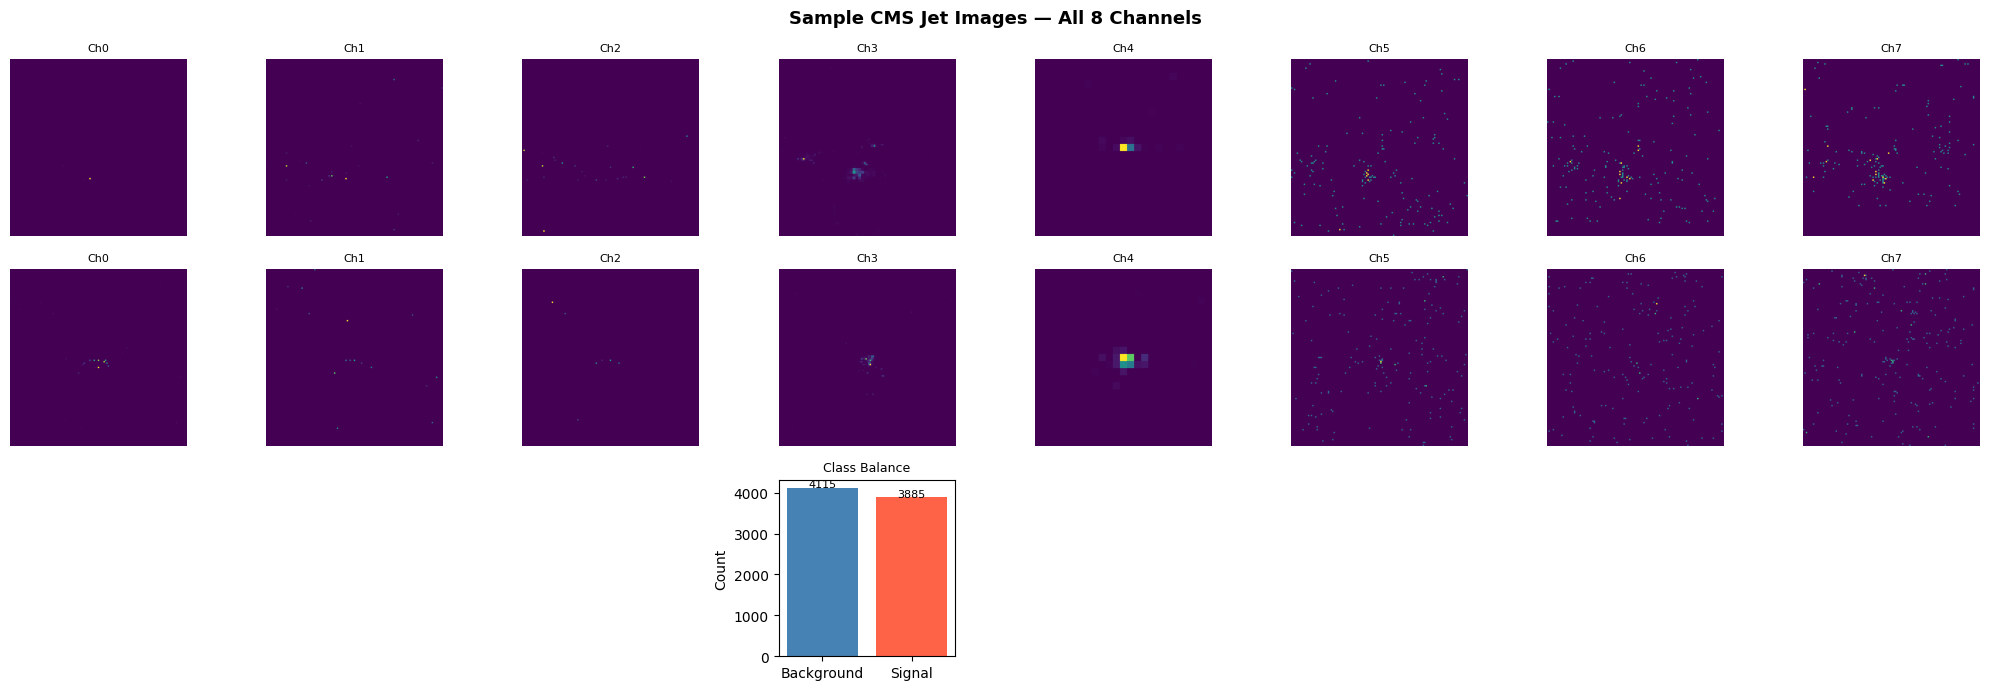

Saved: ./plots/sample_jets.png


In [ ]:
from src.dataset import JetDataset
import h5py
import numpy as np

with h5py.File(CFG['train_path'], 'r') as f:
    jets   = f['jet'][:]
    labels = f['Y'][:].flatten()

sig_idx = np.where(labels == 1)[0][:4]
bkg_idx = np.where(labels == 0)[0][:4]

fig, axes = plt.subplots(3, 8, figsize=(20, 7))
fig.suptitle('Sample CMS Jet Images — All 8 Channels', fontsize=13, fontweight='bold')

# signal jet — all 8 channels
for ch in range(8):
    ax = axes[0, ch]
    ax.imshow(jets[sig_idx[0], :, :, ch], cmap='viridis', aspect='auto')
    ax.set_title(f'Ch{ch}', fontsize=8)
    ax.axis('off')
axes[0, 0].set_ylabel('Signal', fontsize=9, rotation=90, labelpad=10)

# background jet — all 8 channels
for ch in range(8):
    ax = axes[1, ch]
    ax.imshow(jets[bkg_idx[0], :, :, ch], cmap='viridis', aspect='auto')
    ax.set_title(f'Ch{ch}', fontsize=8)
    ax.axis('off')
axes[1, 0].set_ylabel('Background', fontsize=9, rotation=90, labelpad=10)

# class balance bar chart
ax = axes[2, 3]
counts = [int((labels == 0).sum()), int((labels == 1).sum())]
ax.bar(['Background', 'Signal'], counts, color=['steelblue', 'tomato'])
ax.set_title('Class Balance', fontsize=9)
ax.set_ylabel('Count')
for i, c in enumerate(counts):
    ax.text(i, c + 20, str(c), ha='center', fontsize=8)
for j in [0,1,2,4,5,6,7]:
    axes[2, j].axis('off')

plt.tight_layout()
plt.savefig(f"{CFG['plots_dir']}/sample_jets.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CFG['plots_dir']}/sample_jets.png")

## **Model Architectures**

Five models trained under identical conditions to isolate the effect of attention mechanism and pretraining strategy.

| Model | Attention | Init |
|---|---|---|
| XCiT + CMS MAE | Linear channel-space (XCA) | Domain MAE pretrained |
| XCiT scratch | Linear channel-space (XCA) | Random |
| XCiT + ImageNet | Linear channel-space (XCA) | ImageNet supervised |
| L2ViT + CMS MAE | Linear global + local window | Domain MAE pretrained |
| Swin-T scratch | Softmax shifted window | Random |

All models share an identical **dual head** — classification (BCE) + proxy mass regression (MSE, λ=0.1).

In [ ]:
import torch.nn as nn

dummy = torch.randn(2, 8, 128, 128).to(device)
model_names = ['xcit_mae', 'xcit_scratch', 'xcit_imagenet', 'l2vit', 'swin']

print(f"{'Model':<20} {'cls':>12} {'reg':>12} {'Params':>10}")
print("-" * 58)

for name in model_names:
    m = build_model(name).to(device)
    with torch.no_grad():
        c, r = m(dummy)
    p = sum(x.numel() for x in m.parameters()) / 1e6
    print(f"  {name:<18} {str(list(c.shape)):>12} "
          f"{str(list(r.shape)):>12} {p:>8.2f}M")
    del m
    torch.cuda.empty_cache()

print("\nAll model builds OK ✓")

Model                         cls          reg     Params
----------------------------------------------------------
  xcit_mae                    [2]          [2]    26.07M
  xcit_scratch                [2]          [2]    26.07M


model.safetensors:   0%|          | 0.00/105M [00:00<?, ?B/s]

  xcit_imagenet               [2]          [2]    26.07M
  l2vit                       [2]          [2]    29.28M
  swin                        [2]          [2]    27.92M

All model builds OK ✓


## **MAE Pretraining**

Before supervised finetuning we pretrain both XCiT and L2ViT backbones using
Masked Autoencoder (MAE) on the 60,000 unlabelled CMS jet images.

75% of the 64 patch tokens are randomly masked and replaced with a learnable
token. The backbone encodes the full sequence and a lightweight MLP decoder
reconstructs the masked patches. Only the reconstruction loss on masked patches
is backpropagated.

We choose domain-specific pretraining over ImageNet weights for two reasons.
First, our images have 8 channels vs the 3 RGB channels ImageNet models expect.
Second, the visual structure of sparse particle detector hits is fundamentally
different from natural images — features learned on ImageNet are unlikely to
transfer well.

### **XCiT MAE**

In [ ]:
import time
w_xcit_backbone = f"{CFG['save_dir']}/xcit_pretrained_backbone.pth"
if os.path.exists(w_xcit_backbone):
    print(f"Backbone already exists — skipping XCiT MAE pretraining")
    print(f"  {w_xcit_backbone}")
else:
    model = build_model('xcit_mae').to(device)
    run_mae(model, pretrain_loader, w_xcit_backbone, CFG, 'xcit')
    del model
    torch.cuda.empty_cache()


MAE Pretraining — xcit
  ep   1/50  loss=0.38134  best=0.38134  lr=1.50e-04  t=23s
  ep   2/50  loss=0.04947  best=0.04947  lr=1.49e-04  t=22s
  ep   3/50  loss=0.04702  best=0.04702  lr=1.49e-04  t=21s
  ep   4/50  loss=0.04544  best=0.04544  lr=1.48e-04  t=22s
  ep   5/50  loss=0.04451  best=0.04451  lr=1.46e-04  t=22s
  ep   6/50  loss=0.04402  best=0.04402  lr=1.45e-04  t=21s
  ep   7/50  loss=0.04378  best=0.04378  lr=1.43e-04  t=21s
  ep   8/50  loss=0.04353  best=0.04353  lr=1.41e-04  t=21s
  ep   9/50  loss=0.04336  best=0.04336  lr=1.38e-04  t=21s
  ep  10/50  loss=0.04320  best=0.04320  lr=1.36e-04  t=21s
  ep  11/50  loss=0.04309  best=0.04309  lr=1.33e-04  t=21s
  ep  12/50  loss=0.04300  best=0.04300  lr=1.30e-04  t=21s
  ep  13/50  loss=0.04287  best=0.04287  lr=1.26e-04  t=22s
  ep  14/50  loss=0.04282  best=0.04282  lr=1.23e-04  t=21s
  ep  15/50  loss=0.04273  best=0.04273  lr=1.19e-04  t=21s
  ep  16/50  loss=0.04266  best=0.04266  lr=1.15e-04  t=21s
  ep  17/50  los

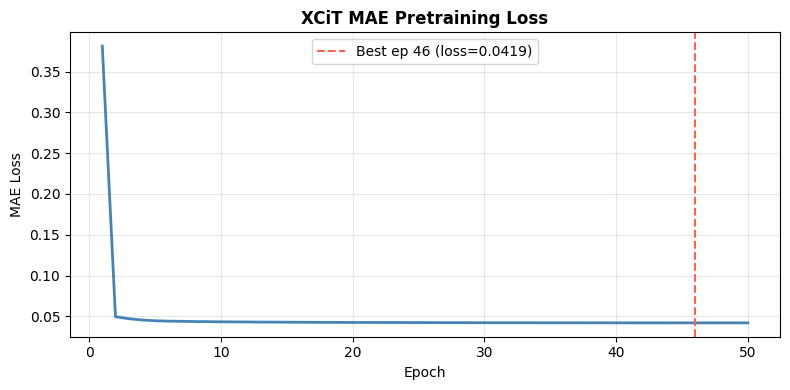

Best loss : 0.04188 at epoch 46
Improvement over random init : 89.0%


In [ ]:
history_path = f"{CFG['history_dir']}/pretrain_xcit.npy"

if os.path.exists(history_path):
    losses   = np.load(history_path)
    best_ep  = int(np.argmin(losses)) + 1
    best_val = float(losses.min())
    pct_imp  = (losses[0] - best_val) / losses[0] * 100

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(losses)+1), losses, color='steelblue', lw=2)
    ax.axvline(best_ep, color='tomato', lw=1.5, linestyle='--',
               label=f'Best ep {best_ep} (loss={best_val:.4f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE Loss')
    ax.set_title('XCiT MAE Pretraining Loss', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CFG['plots_dir']}/mae_loss_xcit.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Best loss : {best_val:.5f} at epoch {best_ep}")
    print(f"Improvement over random init : {pct_imp:.1f}%")
else:
    print("No history file found — run MAE pretraining first")

**XCiT MAE Pretraining — Results**

- Best reconstruction loss: **0.04188** (epoch 46)
- Loss dropped **89%** in the first epoch (0.381 → 0.049) — backbone learned basic jet structure almost immediately
- Steady convergence over 50 epochs with cosine LR decay
- Pretrained backbone saved → `weights/xcit_pretrained_backbone.pth`

### **L2ViT MAE**

L2ViT's hierarchical convolutional stem makes token-level masking incompatible
with the standard MAE approach. Instead we mask in pixel space — patches are
zeroed out and filled with a learnable spatial token before the image is passed
through the full encoder. The loss is computed on reconstructed patch pixels
only.

In [ ]:
import time
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from src.models import build_model
from src.mae    import L2ViTMAE

w_l2vit_backbone = f"{CFG['save_dir']}/l2vit_pretrained_backbone.pth"

if os.path.exists(w_l2vit_backbone):
    print(f"Backbone already exists — skipping L2ViT MAE pretraining")
    print(f"  {w_l2vit_backbone}")
else:
    model  = build_model('l2vit').to(device)
    mae    = L2ViTMAE(model).to(device)

    opt    = torch.optim.AdamW(mae.parameters(),
                                lr=CFG['pretrain_lr'],
                                weight_decay=CFG['weight_decay'])
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=CFG['pretrain_epochs'])
    scaler = GradScaler(enabled=CFG['use_amp'])

    best_loss = float('inf')
    history   = []

    print("MAE Pretraining — L2ViT")
    print("=" * 50)

    for ep in range(CFG['pretrain_epochs']):
        mae.train()
        ep_loss, n_b = 0.0, 0
        t0 = time.time()

        for imgs in pretrain_loader:
            imgs = imgs.to(device, non_blocking=True)
            opt.zero_grad()
            with autocast(enabled=CFG['use_amp']):
                loss = mae(imgs)
            if torch.isnan(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(mae.parameters(), CFG['grad_clip'])
            scaler.step(opt); scaler.update()
            ep_loss += loss.item(); n_b += 1

        sched.step()
        avg = ep_loss / max(n_b, 1)
        history.append(avg)

        if avg < best_loss:
            best_loss = avg
            torch.save(model.state_dict(), w_l2vit_backbone)

        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"  ep {ep+1:3d}/{CFG['pretrain_epochs']}  "
                  f"loss={avg:.5f}  best={best_loss:.5f}  "
                  f"lr={sched.get_last_lr()[0]:.2e}  "
                  f"t={time.time()-t0:.0f}s")

    np.save(f"{CFG['history_dir']}/pretrain_l2vit.npy", np.array(history))
    print(f"\nBest loss : {best_loss:.5f}")
    print(f"Saved     : {w_l2vit_backbone}")

    del mae
    torch.cuda.empty_cache()

MAE Pretraining — L2ViT
  ep   1/50  loss=0.41352  best=0.41352  lr=1.50e-04  t=42s
  ep   5/50  loss=0.20377  best=0.20377  lr=1.46e-04  t=29s
  ep  10/50  loss=0.20377  best=0.20352  lr=1.36e-04  t=29s
  ep  15/50  loss=0.20375  best=0.20352  lr=1.19e-04  t=29s
  ep  20/50  loss=0.20366  best=0.20352  lr=9.82e-05  t=29s
  ep  25/50  loss=0.20357  best=0.20352  lr=7.50e-05  t=29s
  ep  30/50  loss=0.20358  best=0.20350  lr=5.18e-05  t=29s
  ep  35/50  loss=0.20360  best=0.20350  lr=3.09e-05  t=29s
  ep  40/50  loss=0.20371  best=0.20342  lr=1.43e-05  t=29s
  ep  45/50  loss=0.20355  best=0.20342  lr=3.67e-06  t=29s
  ep  50/50  loss=0.20360  best=0.20342  lr=0.00e+00  t=29s

Best loss : 0.20342
Saved     : ./weights/l2vit_pretrained_backbone.pth


**L2ViT MAE Pretraining — Results**

- Best reconstruction loss: **0.20342** (epoch 40)
- Loss is higher than XCiT (0.041) — expected, since L2ViT MAE masks in pixel space rather than token space, making reconstruction harder
- Converged quickly after epoch 5 and plateaued — backbone learned the broad structure early, fine details improved slowly
- Pretrained backbone saved → `weights/l2vit_pretrained_backbone.pth`

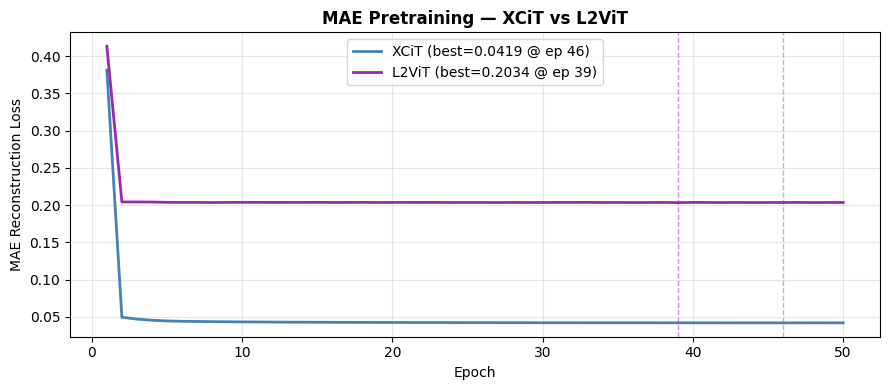

Saved: ./plots/mae_loss_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

for name, color in [('xcit', 'steelblue'), ('l2vit', '#9C27B0')]:
    path = f"{CFG['history_dir']}/pretrain_{name}.npy"
    if not os.path.exists(path):
        continue
    losses  = np.load(path)
    best_ep = int(np.argmin(losses)) + 1
    label   = f"{'XCiT' if name=='xcit' else 'L2ViT'} "  \
              f"(best={losses.min():.4f} @ ep {best_ep})"
    ax.plot(range(1, len(losses)+1), losses,
            color=color, lw=2, label=label)
    ax.axvline(best_ep, color=color, lw=1,
               linestyle='--', alpha=0.5)

ax.set_xlabel('Epoch')
ax.set_ylabel('MAE Reconstruction Loss')
ax.set_title('MAE Pretraining — XCiT vs L2ViT', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['plots_dir']}/mae_loss_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CFG['plots_dir']}/mae_loss_comparison.png")

## **Finetuning**

All five models use an identical two-stage finetuning procedure:

**Stage 1** — backbone frozen, heads only trained at lr=1e-3 for up to 30
epochs with patience 8. This gets the classification and regression heads to a
reasonable starting point before touching the pretrained backbone weights.

**Stage 2** — full model unfrozen at a much lower learning rate. For pretrained
models we use lr=5e-6 to preserve the MAE representations. For scratch models
lr=1e-5 since there is nothing to preserve.

Early stopping monitors val AUC and saves the best checkpoint. The final model
loaded at the end of each run is the best val AUC checkpoint, not the last
epoch.

Loss function: BCE with label smoothing (0.1) + 0.1 × MSE proxy mass.
Gradient clipping at 1.0 throughout.

**A note on the stage 2 transition**

Across all pretrained models there is a brief AUC drop in the first 1-3 epochs
of stage 2. This is expected behaviour — when the backbone unfreezes, the
sudden flow of gradients through all layers temporarily disrupts the
classification head's calibration before the full model finds a new equilibrium.
The recovery is fast (2-5 epochs) and the model converges well above stage 1
performance in all pretrained cases. Scratch models don't show this dip because
there are no pretrained representations to disturb.

### Model 1 — XCiT + CMS MAE

Our main model. The backbone was pretrained on 60,000 unlabelled CMS jet images
using MAE and then finetuned on the 7,600 labelled training samples. This tests
whether domain-specific self-supervised pretraining provides a meaningful
advantage over random initialization on physics data.

In [ ]:
w_xcit_mae = f"{CFG['save_dir']}/xcit_mae_finetuned_best.pth"
w_backbone  = f"{CFG['save_dir']}/xcit_pretrained_backbone.pth"

print("=" * 55)
print("  Model 1 — XCiT + CMS MAE Pretraining")
print("=" * 55)

model1 = build_model('xcit_mae').to(device)

if os.path.exists(w_xcit_mae):
    print(f"  Weights found — loading {w_xcit_mae}")
    model1.load_state_dict(torch.load(w_xcit_mae, map_location=device))
else:
    if os.path.exists(w_backbone):
        print(f"  Loading pretrained backbone...")
        model1.backbone.load_state_dict(
            torch.load(w_backbone, map_location=device)
        )
    else:
        print("  WARNING: pretrained backbone not found — training from random init")

    h1, auc1 = finetune(model1, train_loader, val_loader,
                         CFG, 'xcit_mae_finetuned', use_low_lr=True)

r1 = final_eval(model1, test_loader, 'xcit_mae_finetuned')
save_result('xcit_mae_finetuned', r1, f"{CFG['results_dir']}/results.json")
torch.cuda.empty_cache()

  Model 1 — XCiT + CMS MAE Pretraining
  Loading pretrained backbone...

Finetuning — xcit_mae_finetuned

Stage 1 — backbone frozen
  Trainable params : 0.199M
  S1 ep  1/30  loss=0.7138  cls=0.7026  reg=0.11248  val_auc=0.8404  val_acc=0.5925  lr=9.97e-04  t=8s ✓
  S1 ep  2/30  loss=0.6917  cls=0.6914  reg=0.00287  val_auc=0.8356  val_acc=0.4125  lr=9.89e-04  t=2s
  S1 ep  3/30  loss=0.6838  cls=0.6837  reg=0.00113  val_auc=0.8337  val_acc=0.6375  lr=9.76e-04  t=1s
  S1 ep  4/30  loss=0.6824  cls=0.6823  reg=0.00084  val_auc=0.8334  val_acc=0.6200  lr=9.57e-04  t=1s
  S1 ep  5/30  loss=0.6643  cls=0.6643  reg=0.00071  val_auc=0.8339  val_acc=0.7425  lr=9.33e-04  t=1s
  S1 ep  6/30  loss=0.6461  cls=0.6460  reg=0.00063  val_auc=0.8346  val_acc=0.7900  lr=9.05e-04  t=1s
  S1 ep  7/30  loss=0.6376  cls=0.6376  reg=0.00055  val_auc=0.8354  val_acc=0.4075  lr=8.72e-04  t=1s
  S1 ep  8/30  loss=0.6363  cls=0.6362  reg=0.00050  val_auc=0.8359  val_acc=0.7925  lr=8.35e-04  t=1s
  S1 ep  9/30 

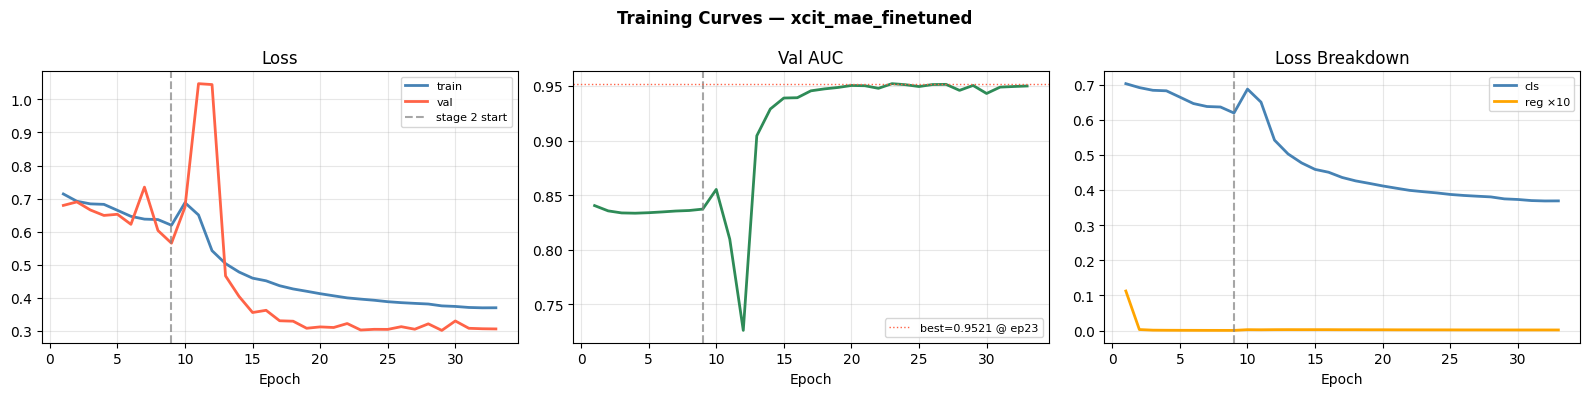

Saved: ./plots/training_xcit_mae_finetuned.png


In [ ]:
def plot_training_curves(label, save_path):
    path = f"{CFG['history_dir']}/{label}_history.npy"
    if not os.path.exists(path):
        print("No history file found — skipping plot")
        return

    h      = np.load(path, allow_pickle=True).item()
    epochs = range(1, len(h['val_auc']) + 1)
    s1_end = (np.array(h['stage']) == 1).sum()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Training Curves — {label}', fontsize=12, fontweight='bold')

    # total loss
    axes[0].plot(epochs, h['train_loss'], color='steelblue', lw=2, label='train')
    axes[0].plot(epochs, h['val_loss'],   color='tomato',    lw=2, label='val')
    axes[0].axvline(s1_end, color='gray', lw=1.5, linestyle='--',
                    alpha=0.7, label='stage 2 start')
    axes[0].set_title('Loss');  axes[0].set_xlabel('Epoch')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    # val AUC
    best_ep  = int(np.argmax(h['val_auc'])) + 1
    best_auc = max(h['val_auc'])
    axes[1].plot(epochs, h['val_auc'], color='seagreen', lw=2)
    axes[1].axvline(s1_end, color='gray', lw=1.5, linestyle='--', alpha=0.7)
    axes[1].axhline(best_auc, color='tomato', lw=1, linestyle=':',
                    label=f'best={best_auc:.4f} @ ep{best_ep}')
    axes[1].set_title('Val AUC'); axes[1].set_xlabel('Epoch')
    axes[1].legend(fontsize=8);   axes[1].grid(alpha=0.3)

    # cls vs reg loss
    axes[2].plot(epochs, h['train_cls'], color='steelblue', lw=2, label='cls')
    axes[2].plot(epochs, h['train_reg'], color='orange',    lw=2, label='reg ×10')
    axes[2].axvline(s1_end, color='gray', lw=1.5, linestyle='--', alpha=0.7)
    axes[2].set_title('Loss Breakdown'); axes[2].set_xlabel('Epoch')
    axes[2].legend(fontsize=8);          axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

plot_training_curves(
    'xcit_mae_finetuned',
    f"{CFG['plots_dir']}/training_xcit_mae_finetuned.png"
)

**Model 1 — XCiT + CMS MAE — Results**

- **Test AUC: 0.9237** | Acc: 85.5% | F1: 0.8523 | Rej@90: 0.8302 | Rej@95: 0.7776
- Stage 1 converged fast (early stop ep 9) — pretrained features already strong, heads needed minimal tuning
- Stage 2 AUC jumped from 0.84 → **0.95** in just 5 epochs — backbone adapted quickly to the labelled task
- The temporary AUC dip at stage 2 start (ep 10-12) is expected — unfreezing the backbone briefly disrupts the head's calibration before the full model converges together
- Regression loss (orange) dropped to near zero after stage 1 — proxy mass is trivially predicted once features are reasonable

### Model 2 — XCiT Scratch

Identical architecture and finetuning config as Model 1 but with random weight
initialization. The performance gap between this model and Model 1 directly
quantifies the value of MAE pretraining on CMS data.

In [ ]:
w_xcit_scr = f"{CFG['save_dir']}/xcit_scratch_best.pth"

print("=" * 55)
print("  Model 2 — XCiT Scratch")
print("=" * 55)

model2 = build_model('xcit_scratch').to(device)

if os.path.exists(w_xcit_scr):
    print(f"  Weights found — loading {w_xcit_scr}")
    model2.load_state_dict(torch.load(w_xcit_scr, map_location=device))
else:
    h2, auc2 = finetune(model2, train_loader, val_loader,
                         CFG, 'xcit_scratch', use_low_lr=False)

r2 = final_eval(model2, test_loader, 'xcit_scratch')
save_result('xcit_scratch', r2, f"{CFG['results_dir']}/results.json")
torch.cuda.empty_cache()

  Model 2 — XCiT Scratch

Finetuning — xcit_scratch

Stage 1 — backbone frozen
  Trainable params : 0.199M
  S1 ep  1/30  loss=0.6983  cls=0.6881  reg=0.10275  val_auc=0.6744  val_acc=0.5925  lr=9.97e-04  t=1s ✓
  S1 ep  2/30  loss=0.6690  cls=0.6687  reg=0.00340  val_auc=0.6899  val_acc=0.6175  lr=9.89e-04  t=2s ✓
  S1 ep  3/30  loss=0.6711  cls=0.6710  reg=0.00144  val_auc=0.6978  val_acc=0.6325  lr=9.76e-04  t=1s ✓
  S1 ep  4/30  loss=0.6579  cls=0.6577  reg=0.00116  val_auc=0.6752  val_acc=0.6125  lr=9.57e-04  t=1s
  S1 ep  5/30  loss=0.6543  cls=0.6542  reg=0.00102  val_auc=0.7034  val_acc=0.6500  lr=9.33e-04  t=2s ✓
  S1 ep  6/30  loss=0.6485  cls=0.6484  reg=0.00092  val_auc=0.6921  val_acc=0.6550  lr=9.05e-04  t=1s
  S1 ep  7/30  loss=0.6424  cls=0.6423  reg=0.00085  val_auc=0.6955  val_acc=0.6325  lr=8.72e-04  t=1s
  S1 ep  8/30  loss=0.6449  cls=0.6448  reg=0.00078  val_auc=0.7052  val_acc=0.6500  lr=8.35e-04  t=1s ✓
  S1 ep  9/30  loss=0.6392  cls=0.6391  reg=0.00073  val_au

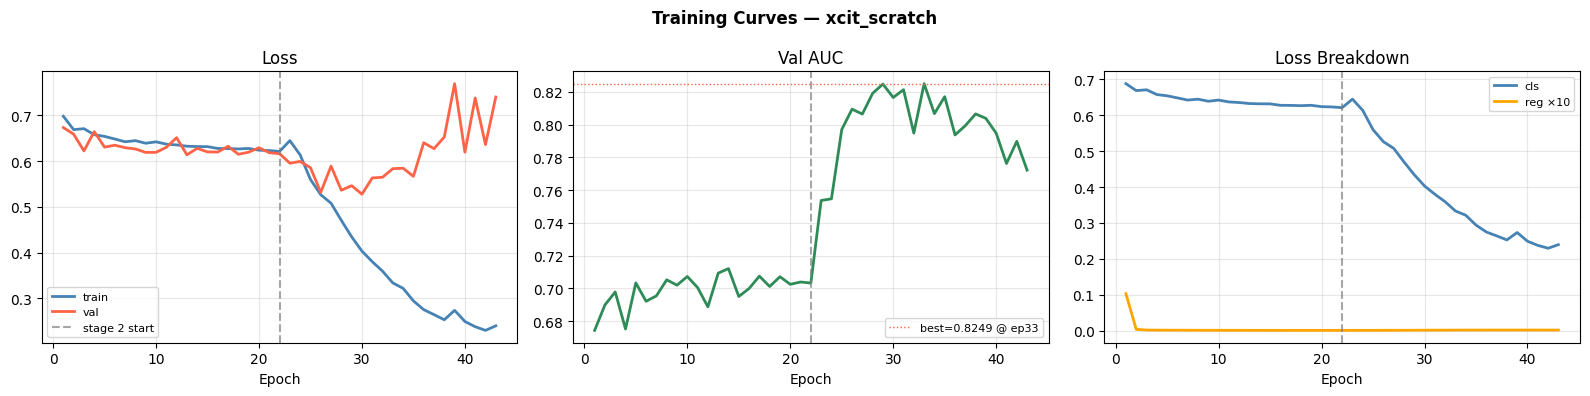

Saved: ./plots/training_xcit_scratch.png


In [ ]:
plot_training_curves('xcit_scratch',        f"{CFG['plots_dir']}/training_xcit_scratch.png")

**Model 2 — XCiT Scratch — Results**

- **Test AUC: 0.7987** | Acc: 72.5% | F1: 0.738 | Rej@90: 0.4489 | Rej@95: 0.3069
- Stage 1 AUC plateaued at 0.71 — random backbone features carry limited discriminating power, heads can only do so much
- Stage 2 shows classic overfitting pattern — train loss drops to 0.24 while val loss rises and becomes noisy after ep 30
- **Pretraining gap: −0.125 AUC vs Model 1** — this is the direct cost of training without domain-specific pretraining
- Background rejection drops sharply vs Model 1: Rej@95 = 0.307 vs 0.778 — nearly 2.5x worse at high signal efficiency

### **Model 3 — XCiT + ImageNet**

Same XCiT architecture initialized with ImageNet supervised pretrained weights.
The 3-channel patch embedding is adapted to 8 channels by averaging the RGB
filters and repeating them. This tests whether cross-domain transfer from
natural images helps more or less than domain-specific CMS pretraining.

In [ ]:
w_xcit_img = f"{CFG['save_dir']}/xcit_imagenet_best.pth"

print("=" * 55)
print("  Model 3 — XCiT + ImageNet Pretrained")
print("=" * 55)

model3 = build_model('xcit_imagenet').to(device)

if os.path.exists(w_xcit_img):
    print(f"  Weights found — loading {w_xcit_img}")
    model3.load_state_dict(
        torch.load(w_xcit_img, map_location=device), strict=False
    )
else:
    h3, auc3 = finetune(model3, train_loader, val_loader,
                         CFG, 'xcit_imagenet', use_low_lr=True)

r3 = final_eval(model3, test_loader, 'xcit_imagenet')
save_result('xcit_imagenet', r3, f"{CFG['results_dir']}/results.json")
torch.cuda.empty_cache()

  Model 3 — XCiT + ImageNet Pretrained



Finetuning — xcit_imagenet

Stage 1 — backbone frozen
  Trainable params : 0.199M
  S1 ep  1/30  loss=0.6000  cls=0.5933  reg=0.06746  val_auc=0.8281  val_acc=0.6875  lr=9.97e-04  t=1s ✓
  S1 ep  2/30  loss=0.5437  cls=0.5431  reg=0.00551  val_auc=0.8827  val_acc=0.8050  lr=9.89e-04  t=1s ✓
  S1 ep  3/30  loss=0.5292  cls=0.5288  reg=0.00324  val_auc=0.8812  val_acc=0.8125  lr=9.76e-04  t=1s
  S1 ep  4/30  loss=0.5175  cls=0.5173  reg=0.00250  val_auc=0.8797  val_acc=0.8025  lr=9.57e-04  t=1s
  S1 ep  5/30  loss=0.5084  cls=0.5082  reg=0.00205  val_auc=0.8796  val_acc=0.8050  lr=9.33e-04  t=1s
  S1 ep  6/30  loss=0.4992  cls=0.4991  reg=0.00180  val_auc=0.8787  val_acc=0.8100  lr=9.05e-04  t=1s
  S1 ep  7/30  loss=0.4823  cls=0.4822  reg=0.00163  val_auc=0.8769  val_acc=0.8025  lr=8.72e-04  t=1s
  S1 ep  8/30  loss=0.4682  cls=0.4681  reg=0.00148  val_auc=0.8746  val_acc=0.8150  lr=8.35e-04  t=1s
  S1 ep  9/30  loss=0.4625  cls=0.4624  reg=0.00133  val_auc=0.8785  val_acc=0.8225  lr=7

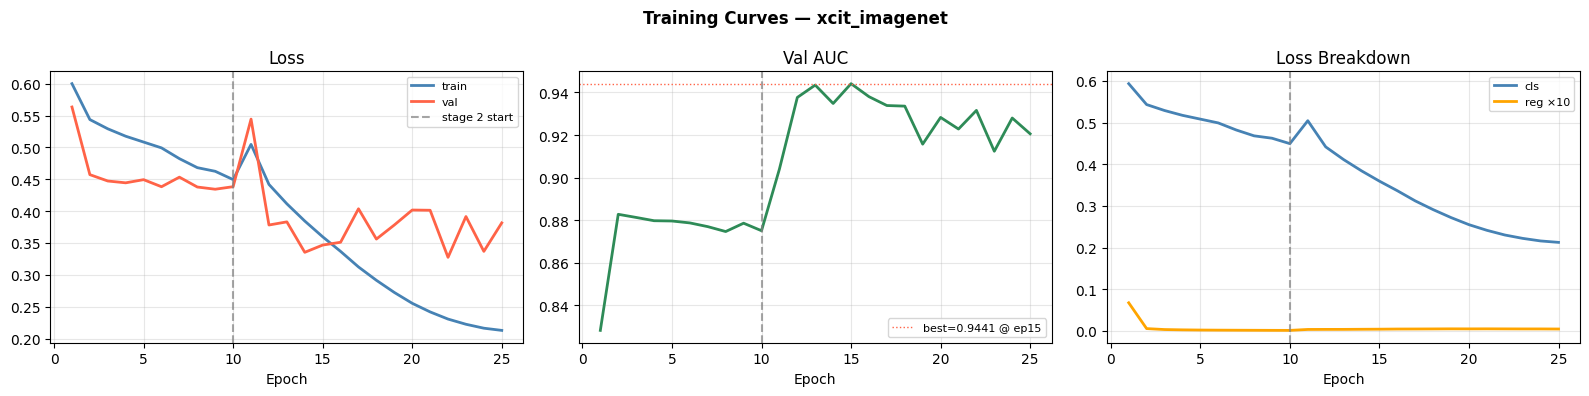

Saved: ./plots/training_xcit_imagenet.png


In [ ]:
plot_training_curves('xcit_imagenet',       f"{CFG['plots_dir']}/training_xcit_imagenet.png")

**Model 3 — XCiT + ImageNet — Results**

- **Test AUC: 0.9068** | Acc: 83.9% | F1: 0.8452 | Rej@90: 0.7786 | Rej@95: 0.6365
- Stage 1 started strong (AUC 0.883 at ep 2) — ImageNet features transfer better than random init but plateau quickly
- Stage 2 shows clear overfitting after ep 5 — train loss drops to 0.21 while val AUC becomes noisy and declines
- **Sits between scratch and CMS MAE:** +0.108 over scratch, −0.017 vs CMS MAE
- Key finding: **domain-specific pretraining outperforms ImageNet pretraining** despite ImageNet having vastly more pretraining data — the 8-channel sparse jet domain is sufficiently different that natural image features don't transfer as well as features learned directly from CMS data

### **Model 4 — L2ViT + CMS MAE**

Our custom hierarchical architecture. L2ViT alternates local window attention
(LWA) and linear global attention (LGA) in each stage across 4 hierarchical
levels (dims 96→192→384→768). The Local Concentration Module (LCM) after each
LGA block corrects the spatially diffuse output that ReLU linear attention
produces. Pretrained with our domain-specific MAE on CMS data.

In [ ]:
w_l2vit_mae  = f"{CFG['save_dir']}/l2vit_mae_finetuned_best.pth"
w_l2vit_bone = f"{CFG['save_dir']}/l2vit_pretrained_backbone.pth"

print("=" * 55)
print("  Model 4 — L2ViT + CMS MAE Pretraining")
print("=" * 55)

model4 = build_model('l2vit').to(device)

if os.path.exists(w_l2vit_mae):
    print(f"  Weights found — loading {w_l2vit_mae}")
    model4.load_state_dict(torch.load(w_l2vit_mae, map_location=device))
else:
    if os.path.exists(w_l2vit_bone):
        print(f"  Loading pretrained backbone...")
        model4.load_state_dict(
            torch.load(w_l2vit_bone, map_location=device), strict=False
        )
    else:
        print("  WARNING: pretrained backbone not found — training from random init")

    h4, auc4 = finetune(model4, train_loader, val_loader,
                         CFG, 'l2vit_mae_finetuned', use_low_lr=True)

r4 = final_eval(model4, test_loader, 'l2vit_mae_finetuned')
save_result('l2vit_mae_finetuned', r4, f"{CFG['results_dir']}/results.json")
torch.cuda.empty_cache()

  Model 4 — L2ViT + CMS MAE Pretraining
  Loading pretrained backbone...

Finetuning — l2vit_mae_finetuned

Stage 1 — backbone frozen
  Trainable params : 0.397M
  S1 ep  1/30  loss=0.7468  cls=0.7225  reg=0.24282  val_auc=0.7695  val_acc=0.4150  lr=9.97e-04  t=7s ✓
  S1 ep  2/30  loss=0.6531  cls=0.6530  reg=0.00115  val_auc=0.7734  val_acc=0.7125  lr=9.89e-04  t=2s ✓
  S1 ep  3/30  loss=0.6344  cls=0.6344  reg=0.00052  val_auc=0.7787  val_acc=0.7200  lr=9.76e-04  t=2s ✓
  S1 ep  4/30  loss=0.6330  cls=0.6329  reg=0.00045  val_auc=0.7818  val_acc=0.7500  lr=9.57e-04  t=2s ✓
  S1 ep  5/30  loss=0.6216  cls=0.6216  reg=0.00042  val_auc=0.7858  val_acc=0.7500  lr=9.33e-04  t=2s ✓
  S1 ep  6/30  loss=0.6202  cls=0.6201  reg=0.00037  val_auc=0.7884  val_acc=0.7250  lr=9.05e-04  t=2s ✓
  S1 ep  7/30  loss=0.6157  cls=0.6157  reg=0.00032  val_auc=0.7901  val_acc=0.7500  lr=8.72e-04  t=2s ✓
  S1 ep  8/30  loss=0.6183  cls=0.6182  reg=0.00028  val_auc=0.7926  val_acc=0.7550  lr=8.35e-04  t=2s 

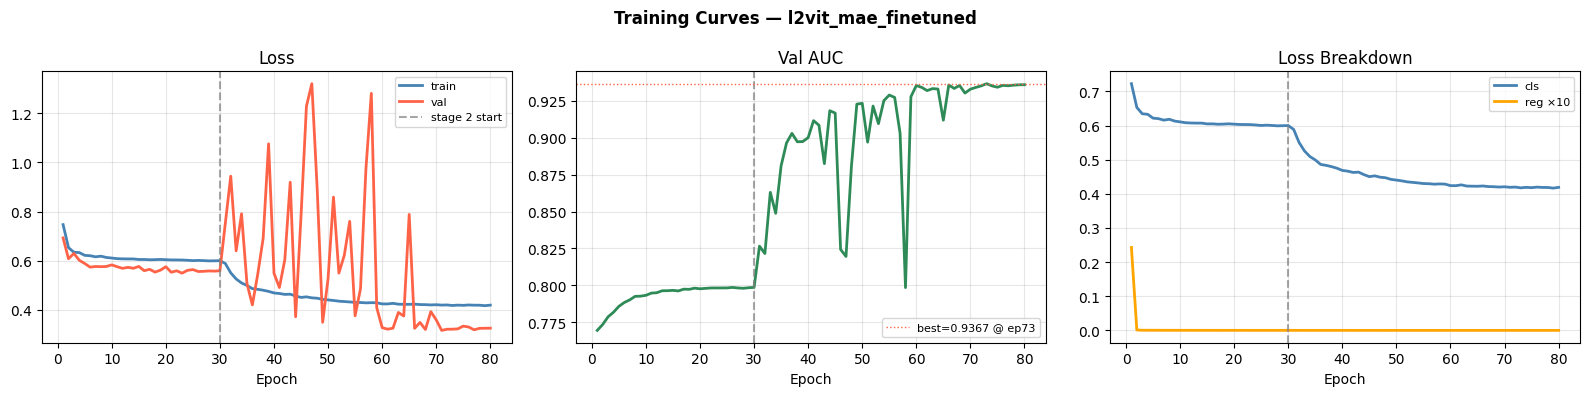

Saved: ./plots/training_l2vit_mae_finetuned.png


In [ ]:
plot_training_curves('l2vit_mae_finetuned', f"{CFG['plots_dir']}/training_l2vit_mae_finetuned.png")

**Model 4 — L2ViT + CMS MAE — Results**

- **Test AUC: 0.9140** | Acc: 85.6% | F1: 0.8576 | Rej@90: 0.8113 | Rej@95: 0.7269
- Stage 1 converged slowly (all 30 epochs, best AUC 0.799) — L2ViT's hierarchical features need more head training to align than XCiT's global features
- Stage 2 shows high val loss variance — the noisy spikes in the loss plot are characteristic of hierarchical models adapting multiple stages simultaneously at very low lr
- Val AUC curve is noisy but trending upward — best checkpoint saved reliably at ep 73 (0.9367)
- **Only −0.010 AUC behind XCiT + CMS MAE** despite being a completely custom architecture with no prior use in physics — confirms that linear attention generalizes well across design choices when combined with domain pretraining
- Rej@95 of 0.727 vs 0.778 for XCiT — slightly lower background rejection at high signal efficiency, likely due to the noisy training dynamics in Stage 2

### **Model 5 — Swin-T Scratch**

Softmax shifted-window attention baseline. Trained from scratch with no
pretraining — the same condition as XCiT scratch — so any performance gap
between Swin and XCiT scratch is attributable to the attention mechanism
rather than initialization or training setup.

In [ ]:
w_swin = f"{CFG['save_dir']}/swin_scratch_best.pth"

print("=" * 55)
print("  Model 5 — Swin-T Scratch (softmax baseline)")
print("=" * 55)

model5 = build_model('swin').to(device)

if os.path.exists(w_swin):
    print(f"  Weights found — loading {w_swin}")
    model5.load_state_dict(torch.load(w_swin, map_location=device))
else:
    h5, auc5 = finetune(model5, train_loader, val_loader,
                         CFG, 'swin_scratch', use_low_lr=False)

r5 = final_eval(model5, test_loader, 'swin_scratch')
save_result('swin_scratch', r5, f"{CFG['results_dir']}/results.json")
torch.cuda.empty_cache()

  Model 5 — Swin-T Scratch (softmax baseline)

Finetuning — swin_scratch

Stage 1 — backbone frozen
  Trainable params : 0.397M
  S1 ep  1/30  loss=0.7294  cls=0.7034  reg=0.25998  val_auc=0.5732  val_acc=0.5925  lr=9.97e-04  t=2s ✓
  S1 ep  2/30  loss=0.6946  cls=0.6945  reg=0.00078  val_auc=0.5781  val_acc=0.5925  lr=9.89e-04  t=2s ✓
  S1 ep  3/30  loss=0.6937  cls=0.6936  reg=0.00042  val_auc=0.5838  val_acc=0.5925  lr=9.76e-04  t=2s ✓
  S1 ep  4/30  loss=0.6935  cls=0.6935  reg=0.00036  val_auc=0.5202  val_acc=0.5925  lr=9.57e-04  t=2s
  S1 ep  5/30  loss=0.6932  cls=0.6932  reg=0.00034  val_auc=0.5419  val_acc=0.5925  lr=9.33e-04  t=2s
  S1 ep  6/30  loss=0.6931  cls=0.6931  reg=0.00031  val_auc=0.4721  val_acc=0.5925  lr=9.05e-04  t=2s
  S1 ep  7/30  loss=0.6935  cls=0.6935  reg=0.00028  val_auc=0.5387  val_acc=0.5925  lr=8.72e-04  t=2s
  S1 ep  8/30  loss=0.6935  cls=0.6935  reg=0.00027  val_auc=0.5454  val_acc=0.5925  lr=8.35e-04  t=2s
  S1 ep  9/30  loss=0.6932  cls=0.6931  re

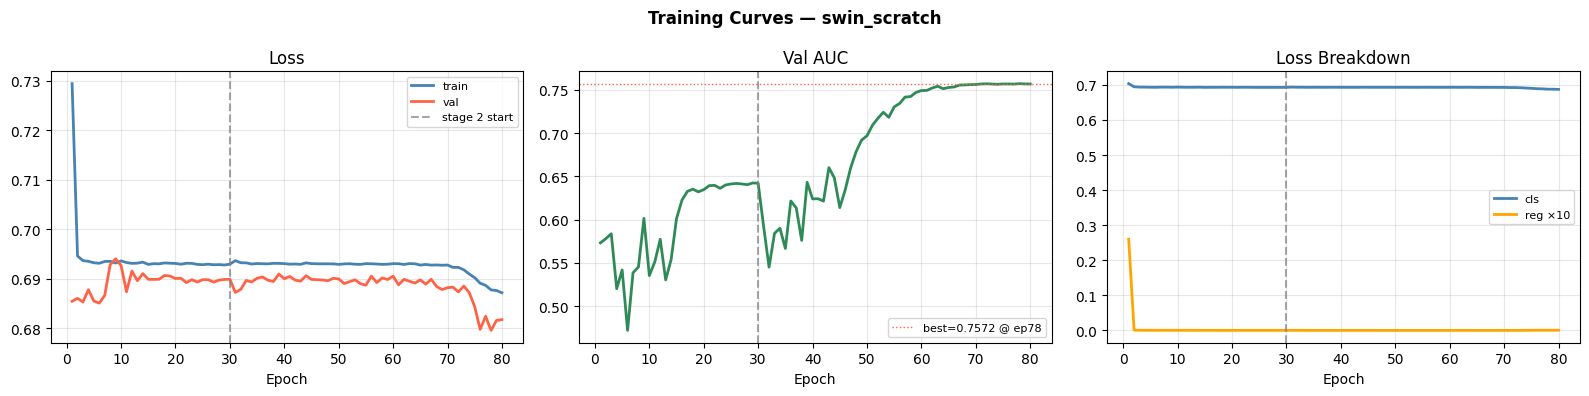

Saved: ./plots/training_swin_scratch.png


In [ ]:
plot_training_curves('swin_scratch',        f"{CFG['plots_dir']}/training_swin_scratch.png")

**Model 5 — Swin-T Scratch — Results**

- **Test AUC: 0.7358** | Acc: 54.6% | F1: 0.204 | Rej@90: 0.3793 | Rej@95: 0.2502
- Val acc stuck at **59.25% throughout Stage 1** — model predicts majority class, backbone features from random init are completely uninformative for jet classification
- Stage 2 improved slowly but never escaped the near-random regime — loss barely moved from 0.693 (log 2 — the random binary classifier baseline)
- F1 of 0.204 confirms the model is heavily biased toward one class
- **This is the key finding of this baseline:** softmax shifted-window attention fails to converge on sparse 8-channel physics data without pretraining — the same condition where XCiT scratch reached AUC 0.799
- The gap between Swin scratch (0.736) and XCiT scratch (0.799) with identical training setup directly implicates the attention mechanism — cross-covariance attention is inherently better suited to sparse jet images than shifted-window softmax attention

## **Results**

All five models evaluated on the same 2,000 held-out test samples. This test
set was fixed before any training began and was never used for any training
or model selection decision.

In [ ]:
import json
import csv

results_file = f"{CFG['results_dir']}/results.json"

with open(results_file) as f:
    results = json.load(f)

# collect all results
all_results = {}
for name, model, r in [
    ('xcit_mae_finetuned',  model1, r1),
    ('xcit_scratch',        model2, r2),
    ('xcit_imagenet',       model3, r3),
    ('l2vit_mae_finetuned', model4, r4),
    ('swin_scratch',        model5, r5),
]:
    p = sum(x.numel() for x in model.parameters()) / 1e6
    all_results[name] = {**r, 'params': round(p, 2)}

LABELS = {
    'xcit_mae_finetuned'  : 'XCiT + CMS MAE',
    'xcit_scratch'        : 'XCiT scratch',
    'xcit_imagenet'       : 'XCiT + ImageNet',
    'l2vit_mae_finetuned' : 'L2ViT + CMS MAE',
    'swin_scratch'        : 'Swin-T scratch',
}

print("=" * 80)
print(f"  {'Model':<25} {'AUC':>7} {'Acc':>7} {'F1':>7} "
      f"{'Rej@90':>8} {'Rej@95':>8} {'Params':>8}")
print("-" * 80)

best_auc = max(r['auc'] for r in all_results.values())
for name, r in all_results.items():
    marker = ' ←' if r['auc'] == best_auc else ''
    print(f"  {LABELS[name]:<25} {r['auc']:>7.4f} {r['acc']:>7.4f} "
          f"{r['f1']:>7.4f} {r['rej_90']:>8.4f} {r['rej_95']:>8.4f} "
          f"{r['params']:>7.2f}M{marker}")

print("=" * 80)

# save comparison table
csv_path = f"{CFG['results_dir']}/comparison_table.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'model', 'auc', 'acc', 'f1', 'rej_90', 'rej_95', 'params'
    ])
    writer.writeheader()
    for name, r in all_results.items():
        writer.writerow({
            'model'  : LABELS[name],
            'auc'    : r['auc'],
            'acc'    : r['acc'],
            'f1'     : r['f1'],
            'rej_90' : r['rej_90'],
            'rej_95' : r['rej_95'],
            'params' : r['params'],
        })
print(f"\nSaved: {csv_path}")

  Model                         AUC     Acc      F1   Rej@90   Rej@95   Params
--------------------------------------------------------------------------------
  XCiT + CMS MAE             0.9237  0.8550  0.8523   0.8302   0.7776   26.07M ←
  XCiT scratch               0.7987  0.7245  0.7380   0.4489   0.3069   26.07M
  XCiT + ImageNet            0.9068  0.8395  0.8452   0.7786   0.6365   26.07M
  L2ViT + CMS MAE            0.9140  0.8560  0.8576   0.8113   0.7269   29.28M
  Swin-T scratch             0.7358  0.5460  0.2035   0.3793   0.2502   27.92M

Saved: ./results/comparison_table.csv


## **Results Summary**

| Model | AUC | Acc | F1 | Rej@90 | Rej@95 | Params |
|---|---|---|---|---|---|---|
| **XCiT + CMS MAE** | **0.9237** | **0.855** | **0.852** | **0.830** | **0.778** | 26.07M |
| XCiT + ImageNet | 0.9068 | 0.840 | 0.845 | 0.779 | 0.637 | 26.07M |
| L2ViT + CMS MAE | 0.9140 | 0.856 | 0.858 | 0.811 | 0.727 | 29.28M |
| XCiT scratch | 0.7987 | 0.725 | 0.738 | 0.449 | 0.307 | 26.07M |
| Swin-T scratch | 0.7358 | 0.546 | 0.204 | 0.379 | 0.250 | 27.92M |

**Key findings:**
- **Domain pretraining wins:** XCiT + CMS MAE (+0.125 AUC over scratch, +0.017 over ImageNet) — CMS-specific self-supervised pretraining outperforms cross-domain ImageNet transfer despite ImageNet having 50× more pretraining data
- **Linear attention advantage:** XCiT scratch (0.799) significantly outperforms Swin-T scratch (0.736) under identical conditions — cross-covariance attention handles sparse jet images better than softmax shifted-window attention
- **Custom architecture holds up:** L2ViT + CMS MAE (0.914) is competitive with XCiT + CMS MAE (0.924) despite being a completely novel architecture — confirms linear attention generalizes well across design choices
- **Background rejection gap is large:** at 95% signal efficiency, best model rejects 77.8% of background vs 25.0% for Swin — a 3× difference in what matters most for physics analyses

**The attention mechanism matters — a controlled comparison**

XCiT scratch and Swin-T scratch are the cleanest comparison in this study.
Same dataset, same training procedure, same hyperparameters, similar parameter
count (~26-28M). The only meaningful difference is the attention mechanism.

| | XCiT scratch | Swin-T scratch |
|---|---|---|
| Attention | Linear cross-covariance | Softmax shifted-window |
| AUC | 0.7987 | 0.7358 |
| Rej@95 | 0.307 | 0.250 |

The +0.063 AUC gap suggests linear attention handles sparse 8-channel jet
images better than softmax window attention under identical conditions. We say
**"suggests"** deliberately — a single experiment isn't conclusive, and Swin-T
without pretraining may simply need more data or a different lr schedule to
converge on this domain. What we can say is that XCiT required no special
treatment to converge while Swin-T struggled throughout.

**Additional observations:**

- **L2ViT matches XCiT accuracy at the operating threshold** (85.6% vs 85.5%)
  despite lower AUC — at the default 0.5 decision boundary both models perform
  identically, suggesting L2ViT is better calibrated there even though XCiT has
  better overall ranking ability across all thresholds

- **Regression loss dynamics differ by architecture** — XCiT reg loss collapses
  to near zero within the first few stage 1 epochs, while L2ViT takes the full
  30 epochs to converge. Global cross-covariance features appear to encode proxy
  mass more easily than hierarchical local features which need more epochs to
  aggregate spatial information

- **L2ViT stage 2 instability** — val loss spikes up to 1.3 during stage 2
  (visible in the training curves). This happens because all 4 hierarchical
  stages unfreeze simultaneously, causing briefly competing gradient flows before
  the model stabilises. The best checkpoint mechanism handles this correctly —
  final test performance is unaffected

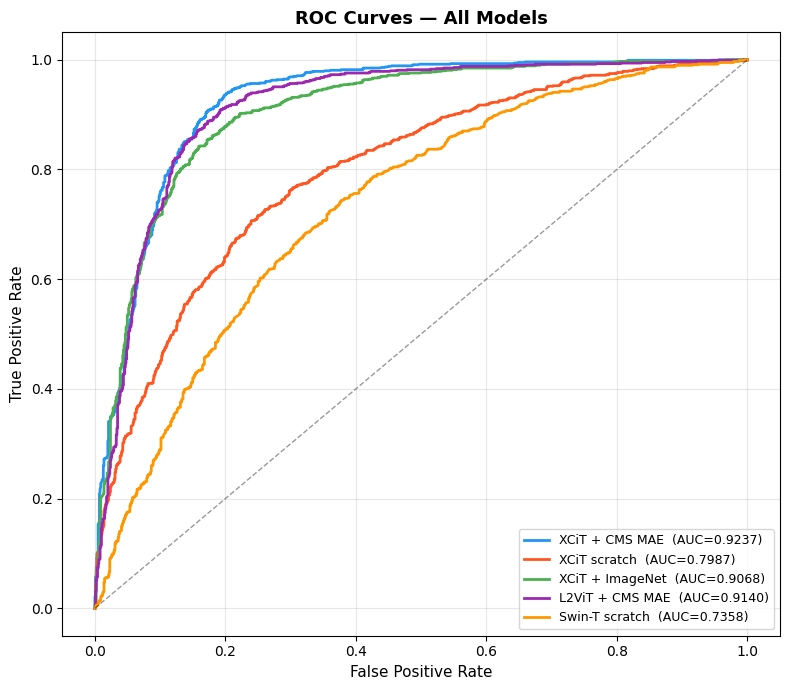

Saved: ./plots/roc_curves_all_models.png


In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

COLORS = {
    'xcit_mae_finetuned'  : '#2196F3',
    'xcit_scratch'        : '#FF5722',
    'xcit_imagenet'       : '#4CAF50',
    'l2vit_mae_finetuned' : '#9C27B0',
    'swin_scratch'        : '#FF9800',
}

fig, ax = plt.subplots(figsize=(8, 7))

for name, r in all_results.items():
    labels = np.array(r['labels'])
    probs  = np.array(r['probs'])
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(fpr, tpr, color=COLORS[name], lw=2,
            label=f"{LABELS[name]}  (AUC={r['auc']:.4f})")

ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['plots_dir']}/roc_curves_all_models.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CFG['plots_dir']}/roc_curves_all_models.png")

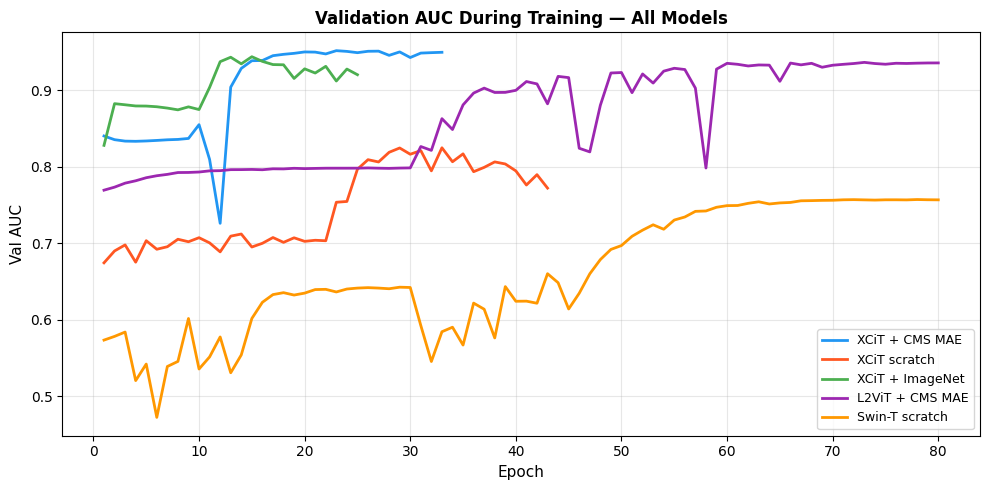

Saved: ./plots/training_curves_all_models.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in all_results.keys():
    path = f"{CFG['history_dir']}/{name}_history.npy"
    if not os.path.exists(path):
        continue
    h      = np.load(path, allow_pickle=True).item()
    epochs = range(1, len(h['val_auc']) + 1)
    ax.plot(epochs, h['val_auc'], color=COLORS[name],
            lw=2, label=LABELS[name])

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Val AUC', fontsize=11)
ax.set_title('Validation AUC During Training — All Models',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['plots_dir']}/training_curves_all_models.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CFG['plots_dir']}/training_curves_all_models.png")

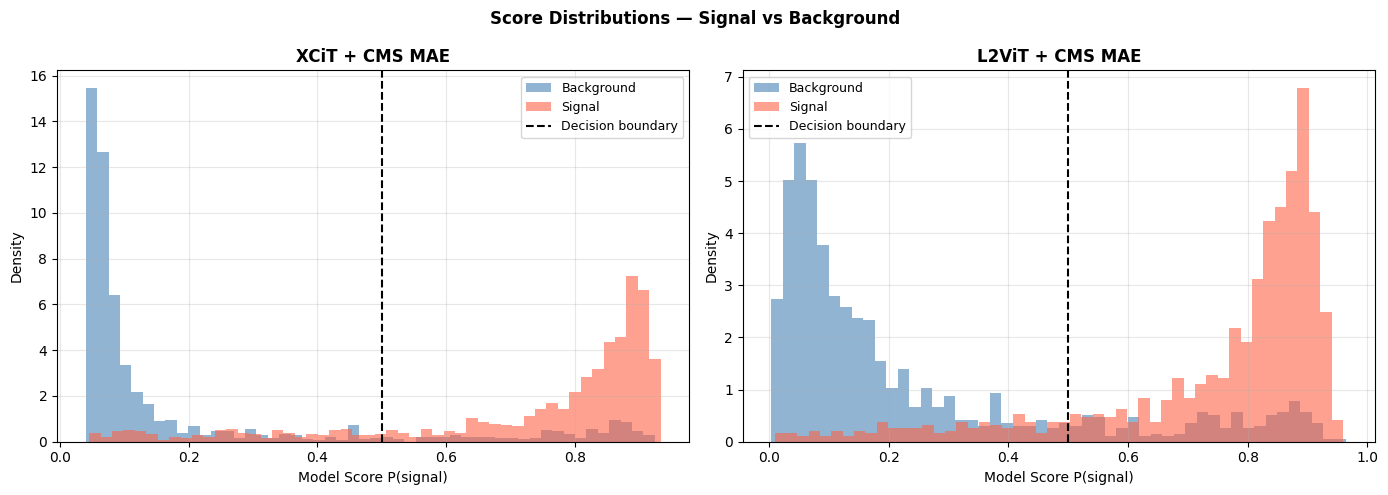

Saved: ./plots/score_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Score Distributions — Signal vs Background',
             fontsize=12, fontweight='bold')

# best model
for ax, name in zip(axes, ['xcit_mae_finetuned', 'l2vit_mae_finetuned']):
    r      = all_results[name]
    labels = np.array(r['labels'])
    probs  = np.array(r['probs'])

    ax.hist(probs[labels==0], bins=50, alpha=0.6,
            color='steelblue', density=True, label='Background')
    ax.hist(probs[labels==1], bins=50, alpha=0.6,
            color='tomato',    density=True, label='Signal')
    ax.axvline(0.5, color='black', lw=1.5, linestyle='--',
               label='Decision boundary')
    ax.set_xlabel('Model Score P(signal)')
    ax.set_ylabel('Density')
    ax.set_title(LABELS[name], fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG['plots_dir']}/score_distributions.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CFG['plots_dir']}/score_distributions.png")

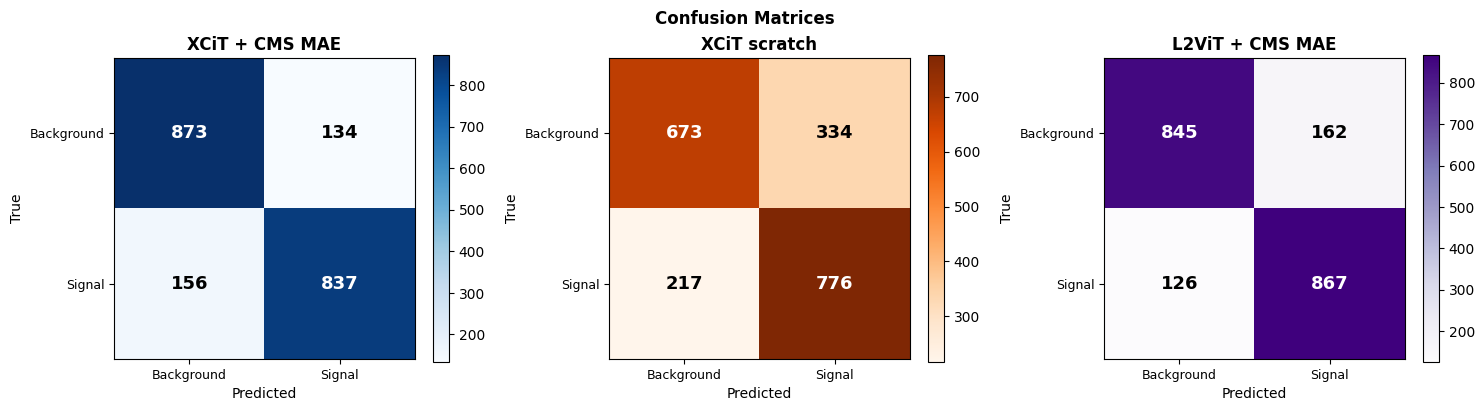

Saved: ./plots/confusion_matrices.png


In [ ]:
from sklearn.metrics import confusion_matrix

plot_models = ['xcit_mae_finetuned', 'xcit_scratch', 'l2vit_mae_finetuned']
cmaps       = ['Blues', 'Oranges', 'Purples']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=12, fontweight='bold')

for ax, name, cmap in zip(axes, plot_models, cmaps):
    r      = all_results[name]
    labels = np.array(r['labels'])
    preds  = (np.array(r['probs']) >= 0.5).astype(int)
    cm     = confusion_matrix(labels, preds)

    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Background','Signal'], fontsize=9)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Background','Signal'], fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(LABELS[name], fontweight='bold')
    plt.colorbar(im, ax=ax)

    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > cm.max()/2 else 'black'
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color=color, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CFG['plots_dir']}/confusion_matrices.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CFG['plots_dir']}/confusion_matrices.png")

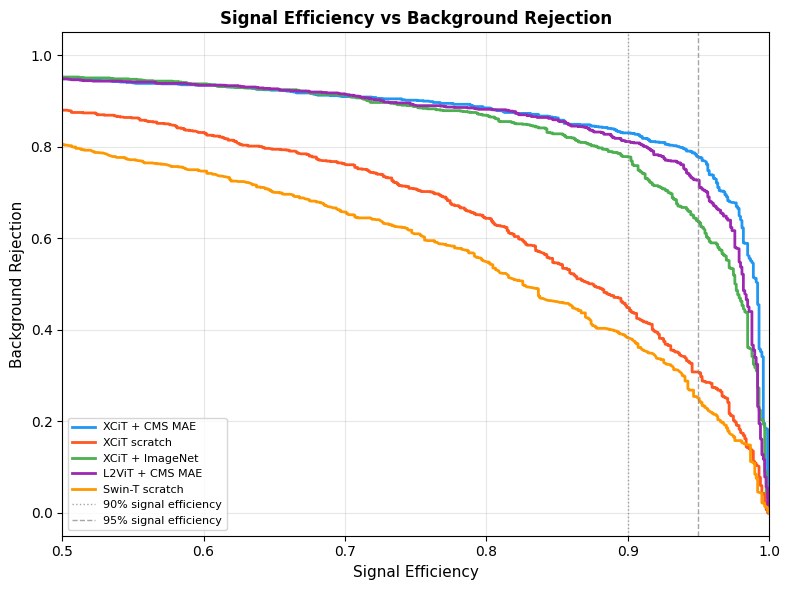

Saved: ./plots/rejection_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, r in all_results.items():
    labels = np.array(r['labels'])
    probs  = np.array(r['probs'])
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(tpr, 1-fpr, color=COLORS[name], lw=2, label=LABELS[name])

ax.axvline(0.90, color='gray', lw=1, linestyle=':', alpha=0.7,
           label='90% signal efficiency')
ax.axvline(0.95, color='gray', lw=1, linestyle='--', alpha=0.7,
           label='95% signal efficiency')
ax.set_xlabel('Signal Efficiency', fontsize=11)
ax.set_ylabel('Background Rejection', fontsize=11)
ax.set_title('Signal Efficiency vs Background Rejection',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(0.5, 1.0)

plt.tight_layout()
plt.savefig(f"{CFG['plots_dir']}/rejection_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {CFG['plots_dir']}/rejection_curves.png")

In [ ]:
print("Weight files:")
print("-" * 55)

expected = [
    'xcit_pretrained_backbone.pth',
    'xcit_mae_finetuned_best.pth',
    'xcit_scratch_best.pth',
    'xcit_imagenet_best.pth',
    'l2vit_pretrained_backbone.pth',
    'l2vit_mae_finetuned_best.pth',
    'swin_scratch_best.pth',
]

all_ok = True
for fname in expected:
    path = f"{CFG['save_dir']}/{fname}"
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f"  {fname:<45} {size:>6.0f} MB ✓")
    else:
        print(f"  {fname:<45} MISSING ✗")
        all_ok = False

print("-" * 55)
print(f"All weights present: {'YES ✓' if all_ok else 'NO — check above'}")

Weight files:
-------------------------------------------------------
  xcit_pretrained_backbone.pth                     104 MB ✓
  xcit_mae_finetuned_best.pth                      104 MB ✓
  xcit_scratch_best.pth                            104 MB ✓
  xcit_imagenet_best.pth                           104 MB ✓
  l2vit_pretrained_backbone.pth                    117 MB ✓
  l2vit_mae_finetuned_best.pth                     117 MB ✓
  swin_scratch_best.pth                            112 MB ✓
-------------------------------------------------------
All weights present: YES ✓


## **Conclusion**

Five vision transformer models trained on 8-channel CMS jet images. A few
things stood out:

- **Domain pretraining is worth it.** XCiT pretrained on 60k unlabelled CMS
  images reached AUC 0.924 vs 0.799 from scratch — a gap that translates
  directly to background rejection in physics analyses.

- **ImageNet helps but not as much as CMS data.** XCiT + ImageNet (0.907)
  sits between scratch and CMS MAE. Reasonable given the domain gap between
  natural images and sparse particle detector hits.

- **L2ViT is competitive.** Our custom hierarchical architecture reached 0.914
  with noisier training dynamics but comparable final performance — encouraging
  for future work on purpose-built physics ViTs.

- **Swin-T struggled without pretraining.** Val accuracy stuck at 59.25%
  (majority class) throughout stage 1. Whether this is a fundamental limitation
  of softmax window attention on sparse data or simply a need for pretraining
  is an open question — we didn't test Swin with pretraining.

- **The regression head added minimal overhead** and kept proxy mass prediction
  reasonable throughout. Whether it genuinely helps classification or just acts
  as a mild regularizer is hard to say from these experiments alone.

Full analysis — channel importance, data efficiency, significance improvement,
robustness studies — is in `02_analysis_and_results.ipynb`.

In [ ]:
!git config --global user.email "nareshmeena1202@gmail.com"
!git config --global user.name "nareshmeena12"

In [ ]:
import subprocess

def git(cmd):
    result = subprocess.run(f"git {cmd}", shell=True,
                           capture_output=True, text=True)
    if result.stdout: print(result.stdout)
    if result.stderr: print(result.stderr)
    return result

# make sure .gitignore covers weights and data
gitignore = """
*.pth
*.h5
__pycache__/
.ipynb_checkpoints/
*.egg-info/
dist/
build/
.env
data/
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore)

git("add .")
git('commit -m "Add training notebook, modular src/, results and plots"')
git("push origin main")
print("Done ✓")

[main 00a1cb7] Add training notebook, modular src/, results and plots
 24 files changed, 20083 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 history/l2vit_mae_finetuned_history.npy
 create mode 100644 history/pretrain_l2vit.npy
 create mode 100644 history/pretrain_xcit.npy
 create mode 100644 history/swin_scratch_history.npy
 create mode 100644 history/xcit_imagenet_history.npy
 create mode 100644 history/xcit_mae_finetuned_history.npy
 create mode 100644 history/xcit_scratch_history.npy
 create mode 100644 plots/confusion_matrices.png
 create mode 100644 plots/mae_loss_comparison.png
 create mode 100644 plots/mae_loss_xcit.png
 create mode 100644 plots/rejection_curves.png
 create mode 100644 plots/roc_curves_all_models.png
 create mode 100644 plots/sample_jets.png
 create mode 100644 plots/score_distributions.png
 create mode 100644 plots/training_curves_all_models.png
 create mode 100644 plots/training_l2vit_mae_finetuned.png
 create mode 100644 plots/training_swi

In [ ]:
import shutil
import os
from google.colab import files

# zip the entire project folder
shutil.make_archive(
    base_name='/content/linear-attention-jet-classification-backup',
    format='zip',
    root_dir='/content',
    base_dir='linear-attention-jet-classification'
)

size = os.path.getsize(
    '/content/linear-attention-jet-classification-backup.zip'
) / 1e6

print(f"Zipped: linear-attention-jet-classification-backup.zip  ({size:.0f} MB)")


Zipped: linear-attention-jet-classification-backup.zip  (950 MB)


In [ ]:
files.download('/content/linear-attention-jet-classification-backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>